<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
  Residual Distribution Analysis 
</p>

#### Core & Data Libraries

In [48]:
#  Core & Visualization 
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator
from matplotlib.lines import Line2D
import matplotlib as mpl
import seaborn as sns
from IPython.display import display

# ML & Stats 
from sklearn.model_selection import KFold
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity

from scipy.stats import kstest, norm, t, skewnorm, cauchy, skew, kurtosis, kruskal, levene
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

#  Parallel control 
from threadpoolctl import threadpool_limits
from joblib import Parallel, delayed

# Other tests 
from diptest import diptest  # Hartigan's dip

#  Utilities 
warnings.filterwarnings("ignore")
rng = np.random.default_rng(42)

import time
# SPEED HEADER (single-BLAS + joblib)
import os
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["NUMEXPR_MAX_THREADS"] = "1"

# Parallelism knob 
n_jobs = -1 

#  Notebook config toggles 
ENABLE_CO2_ANALYSIS = True       # set False to skip CO₂ terciles diagnostics
los_labels = True      # set False to skip LoS terciles diagnostics

def _seeds(base_seed: int, n: int) -> np.ndarray:
    return np.random.default_rng(base_seed).integers(0, 2**32 - 1, size=n, dtype=np.uint32)

#### Load OOF residuals + discover optional columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1663582 entries, 0 to 1663581
Data columns (total 19 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   model        1663582 non-null  object 
 1   split        1663582 non-null  object 
 2   row_id       1663582 non-null  int64  
 3   fold         1663582 non-null  int64  
 4   time         1663582 non-null  object 
 5   device_id    1663582 non-null  object 
 6   distance     1663582 non-null  int64  
 7   frequency    1663582 non-null  float64
 8   c_walls      1663582 non-null  int64  
 9   w_walls      1663582 non-null  int64  
 10  co2          1663582 non-null  float64
 11  humidity     1663582 non-null  float64
 12  pm25         1663582 non-null  float64
 13  pressure     1663582 non-null  float64
 14  temperature  1663582 non-null  float64
 15  snr          1663582 non-null  float64
 16  PL_true      1663582 non-null  float64
 17  PL_pred      1663582 non-null  float64
 18  re

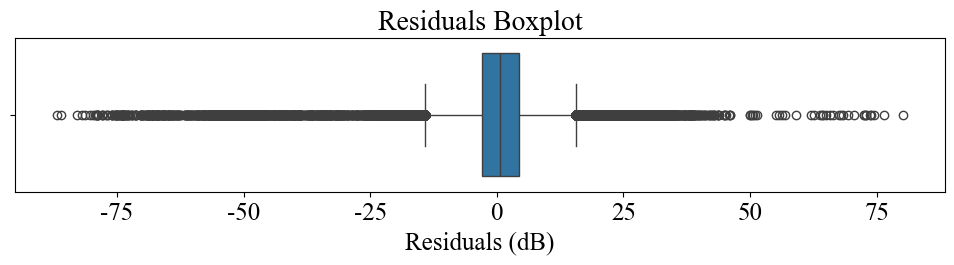

In [49]:
# load residuals 
RESID_PATH = "Residuals/residuals_RNN_oof.csv"
df_res = pd.read_csv(RESID_PATH)

df_res.info()

# detect columns 
res_candidates = ["resid_db", "residuals", "resid", "error"]
res_col = next((c for c in res_candidates if c in df_res.columns), None)
if res_col is None:
    raise KeyError(f"No residual column found; tried {res_candidates}")

col_fold = next((c for c in ["fold", "cv_fold", "group"] if c in df_res.columns), None)
col_dev  = next((c for c in ["device_id","device","ed","ED","node","Device","Node"] if c in df_res.columns), None)
col_los  = next((c for c in ["los","LoS","LOS","is_los"] if c in df_res.columns), None)
col_co2  = next((c for c in ["co2","CO2","co2_ppm","CO2_ppm"] if c in df_res.columns), None)
col_fit  = next((c for c in ["PL_pred","fitted","yhat","y_pred","pred"] if c in df_res.columns), None)

# core arrays 
residuals = df_res[res_col].astype(float).to_numpy()
n = residuals.size

#  LoS/NLoS labels (ED0 treated as LoS)
LOS_DEVICES = {"ED0"} 

if col_los is not None:
    # Use provided LoS column if present
    los_labels = df_res[col_los].astype(str).str.upper().map(lambda s: "LOS" if "LOS" in s else "NLOS")
elif col_dev is not None:
    dev_norm = df_res[col_dev].astype(str).str.strip().str.upper()
    los_set = {d.strip().upper() for d in LOS_DEVICES}
    los_labels = pd.Series(np.where(dev_norm.isin(los_set), "LOS", "NLOS"),
                           index=df_res.index, name="los")
else:
    los_labels = None

if los_labels is not None:
    df_res["los"] = los_labels
    print("LoS counts:", int((los_labels == "LOS").sum()),
          "| NLoS counts:", int((los_labels == "NLOS").sum()))

print("Detected ->",
      f"residual={res_col}, fold={col_fold}, device={col_dev}, los={col_los}, fitted={col_fit}, co2={col_co2}")

#  Q–Q prep
probabilities = (np.arange(1, n + 1) - 0.5) / n
sorted_residuals = np.sort(residuals)

#  quick outlier glimpse 
plt.figure(figsize=(12, 2))
sns.boxplot(x=residuals)
plt.xlabel("Residuals (dB)")
plt.title("Residuals Boxplot")
plt.show()

**Residual diagnostics (normality + tail-heaviness + weak autocorrelation).**  
Omnibus and Jarque–Bera test Normality; skewness/kurtosis quantify tail behavior; Durbin–Watson checks serial correlation (ensure residuals are in chronological order if you want DW to reflect time dependence).

In [50]:
#  Normality + tail + autocorrelation check

res = np.asarray(residuals, dtype=float)
res = res[np.isfinite(res)]

def pfmt(p):
    return "<1e-16" if p < 1e-16 else f"{p:.2e}"

# Prefer statsmodels (matches "Omnibus" and DW used in regression diagnostics); fall back to SciPy if needed.
try:
    from statsmodels.stats.stattools import omni_normtest, jarque_bera, durbin_watson
    omni_stat, omni_p = omni_normtest(res)        # Omnibus (D'Agostino–Pearson)
    jb_stat, jb_p, _, _ = jarque_bera(res)        # Jarque–Bera
    dw = durbin_watson(res)                       # Durbin–Watson (order-sensitive)
except Exception:
    from scipy.stats import normaltest, jarque_bera
    omni_stat, omni_p = normaltest(res)           # D'Agostino–Pearson K^2 (Omnibus-style)
    jb = jarque_bera(res)
    jb_stat, jb_p = float(jb.statistic), float(jb.pvalue)
    dw = np.sum(np.diff(res)**2) / np.sum(res**2) # DW equivalent

sk = skew(res)
ek = kurtosis(res, fisher=True)                   # excess kurtosis

print(f"N = {res.size:,d}")
print(f"Omnibus (D'Agostino): stat = {omni_stat:.2f}, p = {pfmt(omni_p)}")
print(f"Jarque–Bera         : stat = {jb_stat:.2f}, p = {pfmt(jb_p)}")
print(f"Skewness            : {sk:.3f}  (right tail if > 0)")
print(f"Excess kurtosis     : {ek:.3f}  (heavy tails if > 0)")
print(f"Durbin–Watson       : {dw:.3f}  (≈ 2 implies weak autocorrelation)")

N = 1,663,582
Omnibus (D'Agostino): stat = 195447.06, p = <1e-16
Jarque–Bera         : stat = 1909622.54, p = <1e-16
Skewness            : 0.158  (right tail if > 0)
Excess kurtosis     : 5.239  (heavy tails if > 0)
Durbin–Watson       : 1.984  (≈ 2 implies weak autocorrelation)


#### Fit Distributions (PARAMETRIC) 

In [51]:
#  Fit Distributions 

# 1. Normal Distribution
normal_params = norm.fit(residuals)
loc_norm, scale_norm = normal_params
normal_dist = norm(loc=loc_norm, scale=scale_norm)

# 2. Skew-Normal Distribution
skew_params = skewnorm.fit(residuals)
shape_sn, loc_sn, scale_sn = skew_params
skew_dist = skewnorm(shape_sn, loc=loc_sn, scale=scale_sn)

# 3. Gaussian Mixture Model (Automated Model Selection 1 and 2)
residuals_array = residuals.reshape(-1, 1)
lowest_bic = np.inf
bic_scores = []
# up to 5 components
n_components_range = range(1, 6)
best_gmm = None

for n_components in n_components_range:
    gmm_tmp = GaussianMixture(n_components=n_components, random_state=42).fit(residuals_array)
    bic_value = gmm_tmp.bic(residuals_array)
    bic_scores.append(bic_value)
    if bic_value < lowest_bic:
        lowest_bic = bic_value
        best_gmm = gmm_tmp

gmm = best_gmm  # Use the best GMM selected based on the lowest BIC
print(f"\nSelected GMM with {gmm.n_components} components based on lowest BIC: {lowest_bic}")

# 4. Cauchy Distribution
cauchy_params = cauchy.fit(residuals)
cauchy_dist = cauchy(*cauchy_params)

# 5. t-Distribution
t_params = t.fit(residuals)
df_t, loc_t, scale_t = t_params
t_dist = t(df=df_t, loc=loc_t, scale=scale_t)

#  Compute Log-Likelihood, AIC, BIC, and KS Test 
def compute_aic_bic(log_likelihood, num_params, num_samples):
    """Compute AIC and BIC values."""
    aic = 2 * num_params - 2 * log_likelihood
    bic = num_params * np.log(num_samples) - 2 * log_likelihood
    return aic, bic

# Normal Distribution
loglik_norm = np.sum(np.log(normal_dist.pdf(residuals)))
aic_norm, bic_norm = compute_aic_bic(loglik_norm, 2, n)  # 2 params: loc, scale
ks_norm = kstest(residuals, normal_dist.cdf)

# Skew-Normal Distribution
loglik_sn = np.sum(np.log(skew_dist.pdf(residuals)))
aic_sn, bic_sn = compute_aic_bic(loglik_sn, 3, n)  # 3 params: shape, loc, scale
ks_sn = kstest(residuals, skew_dist.cdf)

# Robust GMM CDF helper (handles different covariance shapes)
def gmm_cdf(x, gmm_model):
    x = np.asarray(x)
    means = gmm_model.means_.ravel()
    covs = gmm_model.covariances_
    if covs.ndim == 3:
        covs = covs[:, 0, 0]
    elif covs.ndim == 2:
        covs = covs[:, 0]
    stds = np.sqrt(covs)
    weights = gmm_model.weights_.ravel()
    cdf = np.zeros_like(x, dtype=float)
    for w, m, s in zip(weights, means, stds):
        cdf += w * norm.cdf(x, loc=m, scale=s)
    return cdf

# Gaussian Mixture Model
# score() returns average log-likelihood; multiply by n for total
loglik_gmm = gmm.score(residuals_array) * n
# Parameter count for univariate GMM: (k-1) weights + k means + k variances = 3k - 1
aic_gmm, bic_gmm = compute_aic_bic(loglik_gmm, 3 * gmm.n_components - 1, n)
ks_gmm = kstest(residuals, lambda x: gmm_cdf(x, gmm))

# Cauchy Distribution
loglik_cauchy = np.sum(np.log(cauchy_dist.pdf(residuals)))
aic_cauchy, bic_cauchy = compute_aic_bic(loglik_cauchy, 2, n)  # 2 params: loc, scale
ks_cauchy = kstest(residuals, cauchy_dist.cdf)

# t-Distribution
loglik_t = np.sum(np.log(t_dist.pdf(residuals)))
aic_t, bic_t = compute_aic_bic(loglik_t, 3, n)  # 3 params: df, loc, scale
ks_t = kstest(residuals, t_dist.cdf)

#  Compile Diagnostics into a DataFrame 
diagnostics = pd.DataFrame({
    'Distribution': ['Normal', 'Skew-Normal', 'Gaussian Mixture Model', 'Cauchy', 't-Distribution'],
    'Log-Likelihood': [loglik_norm, loglik_sn, loglik_gmm, loglik_cauchy, loglik_t],
    'AIC': [aic_norm, aic_sn, aic_gmm, aic_cauchy, aic_t],
    'BIC': [bic_norm, bic_sn, bic_gmm, bic_cauchy, bic_t],
    'KS Test Statistic': [ks_norm.statistic, ks_sn.statistic, ks_gmm.statistic, ks_cauchy.statistic, ks_t.statistic],
    'KS Test p-value': [ks_norm.pvalue, ks_sn.pvalue, ks_gmm.pvalue, ks_cauchy.pvalue, ks_t.pvalue]
})

diagnostics['Log-Likelihood'] = diagnostics['Log-Likelihood'].round(2)
diagnostics['AIC'] = diagnostics['AIC'].round(2)
diagnostics['BIC'] = diagnostics['BIC'].round(2)
diagnostics['KS Test Statistic'] = diagnostics['KS Test Statistic'].round(4)
diagnostics['KS Test p-value'] = diagnostics['KS Test p-value'].round(4)

print("\nDiagnostics Table:")
display(diagnostics)

best_fit = diagnostics.loc[diagnostics['KS Test Statistic'].idxmin()]
print(f"\nBest Fit (Based on KS Test Statistic): {best_fit['Distribution']}\n")


Selected GMM with 3 components based on lowest BIC: 10582523.64331085

Diagnostics Table:


,Distribution,Log-Likelihood,AIC,BIC,KS Test Statistic,KS Test p-value
0,Normal,-5342133.74,10684271.48,10684296.12,0.0380,0.0
1,Skew-Normal,-5330421.19,10660848.39,10660885.36,0.0263,0.0
2,Gaussian Mixture Model,-5291204.52,10582425.05,10582523.64,0.0088,0.0
3,Cauchy,-5540788.76,11081581.51,11081606.16,0.0826,0.0
4,t-Distribution,-5296555.91,10593117.82,10593154.79,0.0182,0.0



Best Fit (Based on KS Test Statistic): Gaussian Mixture Model



#### GMM Diagnostics (1–5 components)

In [52]:
# Convert residuals to a 2D array for GMM (required shape: [n_samples, n_features])
gmm_models = []  # Define and initialize the list

# Initialize a list to store diagnostics for each GMM with different numbers of components
gmm_diagnostics = []

# Loop over the number of components (1 through 5)
for k in range(1, 6):
    # Fit GMM with k components using a fixed random state for reproducibility
    gmm_k = GaussianMixture(n_components=k, random_state=42).fit(residuals_array)
    gmm_models.append(gmm_k)
    
    # Calculate the total log-likelihood from the per-sample log probabilities.
    # Note: score_samples returns the log probability for each sample.
    loglik_k = np.sum(gmm_k.score_samples(residuals_array))
    
    # Estimate the number of free parameters for a mixture of Gaussians.
    # For each component: 1 weight (but total weights sum to 1: hence, k - 1 free parameters),
    # 1 mean, and 1 variance. Total parameters: (k - 1) + k + k = 3k - 1.
    num_params = 3 * k - 1
    
    # Compute AIC and BIC using standard formulas:    
    aic_k = 2 * num_params - 2 * loglik_k
    bic_k = num_params * np.log(len(residuals_array)) - 2 * loglik_k
    
    # Perform a Kolmogorov–Smirnov (KS) test on the residuals versus the GMM cumulative distribution.
    # We use our custom gmm_cdf function defined earlier.
    ks_result = kstest(residuals, lambda x: gmm_cdf(x, gmm_k))
    
    # Append the diagnostics for the current model to our list
    gmm_diagnostics.append({
        'GMM Components': k,
        'Log-Likelihood': loglik_k,
        'AIC': aic_k,
        'BIC': bic_k,
        'KS Statistic': ks_result.statistic,
        'KS p-value': ks_result.pvalue
    })

# Convert the collected diagnostics to a DataFrame
gmm_diag_df = pd.DataFrame(gmm_diagnostics)

print("\n GMM Diagnostics (Modes 1-5) n")
display(gmm_diag_df)

# Select the best GMM based on the minimum AIC value (or BIC)
best_gmm_row = gmm_diag_df.loc[gmm_diag_df['BIC'].idxmin()]
best_gmm_components = best_gmm_row['GMM Components']
best_gmm = gmm_models[int(best_gmm_components) - 1]
print(f"\nBest GMM Model based on lowest BIC: {int(best_gmm_components)} components\n")


 GMM Diagnostics (Modes 1-5) n


,GMM Components,Log-Likelihood,AIC,BIC,KS Statistic,KS p-value
0,1,-5.342134e+06,1.068427e+07,1.068430e+07,0.038016,0.000000e+00
1,2,-5.298463e+06,1.059694e+07,1.059700e+07,0.014580,1.392302e-307
2,3,-5.291205e+06,1.058243e+07,1.058252e+07,0.008788,4.954302e-112
3,4,-5.306371e+06,1.061276e+07,1.061290e+07,0.009923,1.040700e-142
4,5,-5.297249e+06,1.059453e+07,1.059470e+07,0.006843,4.362700e-68



Best GMM Model based on lowest BIC: 3 components



In [53]:
# Q-Q tail error: empirical vs fitted quantiles in lower and upper tails

TAIL_PROB_LOW = 0.05
TAIL_PROB_HIGH = 0.95
N_QQ_TAIL_POINTS = 200
PPF_GRID_SIZE = 50_000

res = np.asarray(residuals, dtype=float)
res = res[np.isfinite(res)]

p_low = np.linspace(0.001, TAIL_PROB_LOW, N_QQ_TAIL_POINTS)
p_high = np.linspace(TAIL_PROB_HIGH, 0.999, N_QQ_TAIL_POINTS)

def qq_tail_metrics(empirical_q, model_q):
    err = empirical_q - model_q
    return {
        "tail_rmse": float(np.sqrt(np.mean(err ** 2))),
        "tail_mae": float(np.mean(np.abs(err))),
        "tail_bias": float(np.mean(err)),
        "tail_max_abs": float(np.max(np.abs(err))),
    }

def gmm_ppf_from_existing_cdf(p_grid, gmm_model, reference_values):
    ref = np.asarray(reference_values, dtype=float)

    means = gmm_model.means_.ravel()
    covs = gmm_model.covariances_
    if covs.ndim == 3:
        covs = covs[:, 0, 0]
    elif covs.ndim == 2:
        covs = covs[:, 0]
    stds = np.sqrt(covs)

    lo = min(ref.min(), np.min(means - 8 * stds))
    hi = max(ref.max(), np.max(means + 8 * stds))

    x_grid = np.linspace(lo, hi, PPF_GRID_SIZE)
    cdf_grid = np.maximum.accumulate(gmm_cdf(x_grid, gmm_model))

    unique_cdf, unique_idx = np.unique(cdf_grid, return_index=True)
    unique_x = x_grid[unique_idx]

    return np.interp(p_grid, unique_cdf, unique_x)

fitted_distributions = {
    "Normal": normal_dist,
    "SkewNormal": skew_dist,
    "Cauchy": cauchy_dist,
    "StudentT": t_dist,
}

tail_error_rows = []

for tail_name, p_grid in {
    "lower": p_low,
    "upper": p_high,
    "both": np.r_[p_low, p_high],
}.items():

    empirical_q = np.quantile(res, p_grid)

    for dist_name, dist_obj in fitted_distributions.items():
        model_q = dist_obj.ppf(p_grid)
        metrics = qq_tail_metrics(empirical_q, model_q)

        tail_error_rows.append({
            "distribution": dist_name,
            "tail": tail_name,
            "p_min": float(np.min(p_grid)),
            "p_max": float(np.max(p_grid)),
            "n_quantile_points": len(p_grid),
            **metrics,
        })

    gmm_q = gmm_ppf_from_existing_cdf(p_grid, best_gmm, res)
    metrics = qq_tail_metrics(empirical_q, gmm_q)

    tail_error_rows.append({
        "distribution": f"GMM(K={best_gmm.n_components})",
        "tail": tail_name,
        "p_min": float(np.min(p_grid)),
        "p_max": float(np.max(p_grid)),
        "n_quantile_points": len(p_grid),
        **metrics,
    })

qq_tail_error_table = pd.DataFrame(tail_error_rows)

display(
    qq_tail_error_table
    .sort_values(["tail", "tail_rmse"])
    .round(5)
)

,distribution,tail,p_min,p_max,n_quantile_points,tail_rmse,tail_mae,tail_bias,tail_max_abs
14,GMM(K=3),both,0.001,0.999,400,0.68053,0.50946,-0.38530,1.35253
11,SkewNormal,both,0.001,0.999,400,1.17120,0.88680,0.87846,4.71057
10,Normal,both,0.001,0.999,400,1.94058,1.63703,1.63703,6.64948
13,StudentT,both,0.001,0.999,400,2.12553,1.84893,1.84893,6.30796
12,Cauchy,both,0.001,0.999,400,153.54392,75.94306,2.12159,1058.69379
4,GMM(K=3),lower,0.001,0.050,200,0.25731,0.14308,0.10525,0.97799
1,SkewNormal,lower,0.001,0.050,200,0.87787,0.85010,0.84570,1.26196
0,Normal,lower,0.001,0.050,200,1.66958,1.60944,1.60944,2.55197
3,StudentT,lower,0.001,0.050,200,2.55870,2.21913,2.21913,6.30796
2,Cauchy,lower,0.001,0.050,200,155.21525,78.06465,78.06465,1058.69379


#### Q–Q Plots for GMMs + Histogram Overlay

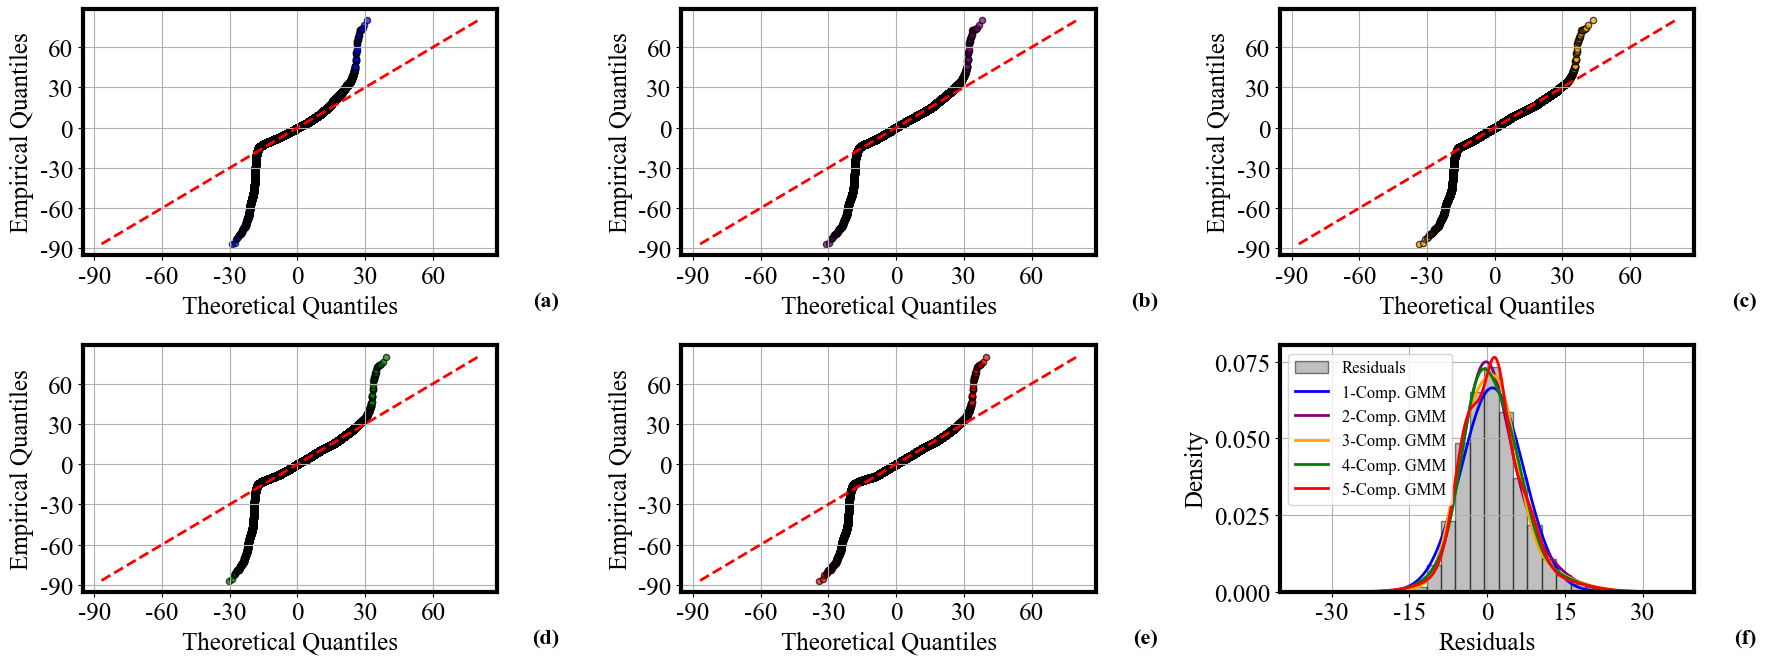

In [54]:
#  Re-fit GMM models for 1 to 5 components and store them in a list 
gmm_models = []
for k in range(1, 6):
    gmm_k = GaussianMixture(n_components=k, random_state=42).fit(residuals_array)
    gmm_models.append(gmm_k)

# Prepare sorted residuals and the corresponding probability positions
sorted_residuals = np.sort(residuals)
n = len(sorted_residuals)
probs = (np.arange(1, n + 1) - 0.5) / n  # Probability positions for quantiles

# Create a 2x3 grid for Q–Q plots and the combined histogram 
fig, axes = plt.subplots(2, 3, figsize=(18, 7))
axes = axes.flatten()
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
gmm_colors = ['blue', 'purple', 'orange', 'green', 'red']

# Plot Q–Q plots for each of the 5 GMM models 
for i, gmm_model in enumerate(gmm_models):
    ax = axes[i]
    
    # Generate a dense grid to compute the GMM CDF
    x_grid = np.linspace(residuals.min(), residuals.max(), 200000)
    cdf_grid = gmm_cdf(x_grid, gmm_model)
    
    # Remove duplicate CDF values for reliable interpolation
    unique_cdf, unique_idx = np.unique(cdf_grid, return_index=True)
    unique_x = x_grid[unique_idx]
    # Create an interpolation function (PPF) from CDF to quantiles
    ppf_func = interp1d(unique_cdf, unique_x, bounds_error=False, fill_value=(x_grid[0], x_grid[-1]))
    theoretical_quantiles = ppf_func(probs)
    
    # Scatter the theoretical versus empirical quantiles
    ax.scatter(theoretical_quantiles, sorted_residuals, color=gmm_colors[i], alpha=0.7, edgecolors='k', s=20)
    # Plot a 45° reference line
    min_val = min(theoretical_quantiles.min(), sorted_residuals.min())
    max_val = max(theoretical_quantiles.max(), sorted_residuals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    ax.set_xlabel('Theoretical Quantiles', fontsize=18)
    ax.set_ylabel('Empirical Quantiles', fontsize=18)
    #ax.set_title(f'GMM with {i+1} Component(s)', fontsize=20)
    ax.text(1.15, -0.15, subplot_labels[i], transform=ax.transAxes, ha='right', va='top', fontweight='bold', fontsize=16)
    ax.grid(True)

#  Plot the 6th subplot: Histogram of residuals with overlaid GMM densities 
ax6 = axes[5]
ax6.hist(residuals, bins=60, density=True, alpha=0.5, color='grey', edgecolor='black', label='Residuals')
x_vals = np.linspace(residuals.min(), residuals.max(), 1000)
for i, gmm_model in enumerate(gmm_models):
    # Compute the density for the current GMM (exponentiate the log probabilities)
    density = np.exp(gmm_model.score_samples(x_vals.reshape(-1, 1)))
    ax6.plot(x_vals, density, color=gmm_colors[i], linewidth=2, label=f'{i+1}-Comp. GMM')
    
ax6.set_xlabel('Residuals', fontsize=18)
ax6.set_ylabel('Density', fontsize=18)
ax6.legend(fontsize=12)
ax6.set_xlim(-40, 40)
ax6.grid(True)
ax6.text(1.15, -0.15, subplot_labels[5], transform=ax6.transAxes, ha='right', va='top', fontweight='bold', fontsize=16)

# Set tick intervals and font sizes
for i, ax in enumerate(axes):
    if i < 5:  # Subplots (a) to (e)
        ax.xaxis.set_major_locator(MultipleLocator(30))
        ax.yaxis.set_major_locator(MultipleLocator(30))
    elif i == 5:  # Subplot (f)
        ax.xaxis.set_major_locator(MultipleLocator(15))
    
    # Set tick font size
    ax.tick_params(axis='both', which='major', labelsize=18)
    
    # Set border width
    for spine in ax.spines.values():
        spine.set_linewidth(3)
        
plt.tight_layout()
#plt.savefig('Figures/gmm_qq_residual_plots.png', dpi=1000)
plt.show()

#### Print Distribution Parameters

In [55]:
#  Print Distribution Parameters Including Best GMM 

def print_group(title, params):
    bold_title = f"\033[1m=== {title} ===\033[0m"
    print(bold_title)
    for name, val in params:
        print(f"{name}: {val:.4f}")
    print("-" * 50)

# Normal Distribution
print_group("Normal Distribution", [("Mean (μ)", loc_norm), ("Std (σ)", scale_norm)])

# Skew-Normal Distribution
print_group("Skew-Normal Distribution", [("Shape", shape_sn), ("Location", loc_sn), ("Scale", scale_sn)])

# Gaussian Mixture Model (Using Best GMM from Diagnostics)
bold_title = f"\033[1m=== Gaussian Mixture Model (Best GMM) ===\033[0m"
print(bold_title)
for i in range(best_gmm.n_components):
    print(f"Component {i+1}:")
    print(f"  Weight (π): {best_gmm.weights_[i]:.4f}")
    if best_gmm.covariances_.ndim == 3:
        std = np.sqrt(best_gmm.covariances_[i][0][0])
    else:
        std = np.sqrt(best_gmm.covariances_[i])
    mean = best_gmm.means_[i][0]
    print(f"  Mean (μ):   {mean:.4f}")
    print(f"  Std (σ):    {std:.4f}")
print("-" * 50)

# Cauchy Distribution
print_group("Cauchy Distribution", [("Location", cauchy_params[0]), ("Scale", cauchy_params[1])])

# t-Distribution
print_group("t-Distribution", [("Degrees of Freedom (df)", df_t), ("Location", loc_t), ("Scale", scale_t)])

=== Normal Distribution ===
Mean (μ): 1.0044
Std (σ): 6.0032
--------------------------------------------------
=== Skew-Normal Distribution ===
Shape: 1.2757
Location: -3.7940
Scale: 7.6852
--------------------------------------------------
=== Gaussian Mixture Model (Best GMM) ===
Component 1:
  Weight (π): 0.4412
  Mean (μ):   2.4529
  Std (σ):    3.5241
Component 2:
  Weight (π): 0.3303
  Mean (μ):   -3.6456
  Std (σ):    3.3297
Component 3:
  Weight (π): 0.2285
  Mean (μ):   4.9303
  Std (σ):    8.1853
--------------------------------------------------
=== Cauchy Distribution ===
Location: 0.5199
Scale: 3.3790
--------------------------------------------------
=== t-Distribution ===
Degrees of Freedom (df): 8.0352
Location: 0.7925
Scale: 5.1392
--------------------------------------------------


#### Diagnostic Subplots 2×3 (Normal, Skew, best GMM, Cauchy, t, Histogram)

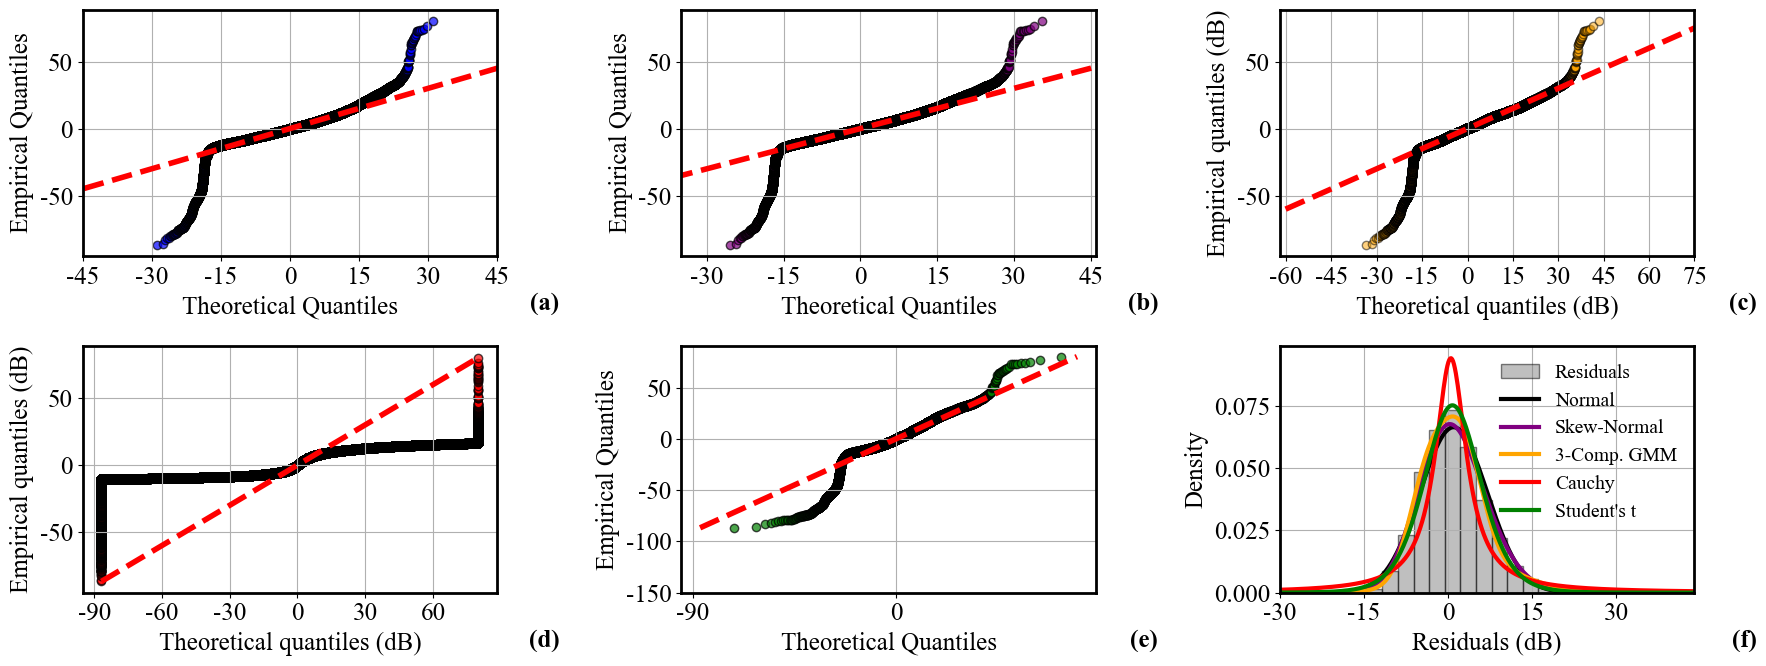

In [56]:
# Plot Diagnostic Subplots in a 2x3 Grid

plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 15
})

fig, axes = plt.subplots(2, 3, figsize=(18, 7))  # 2 rows, 3 columns
axes = axes.flatten()  # Flatten to 1D array for easy indexing

# Define subplot labels for the six subplots
subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# Function to create manual Q-Q plots
def manual_qq_plot(distribution, dist_name, sorted_residuals, probabilities, ax, color='blue'):
    """
    Create a manual Q-Q plot.
    """
    theoretical_quantiles = distribution.ppf(probabilities)
    ax.scatter(theoretical_quantiles, sorted_residuals, edgecolors='k', facecolor=color, alpha=0.7)
    min_val = min(theoretical_quantiles.min(), sorted_residuals.min())
    max_val = max(theoretical_quantiles.max(), sorted_residuals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=4)
    #ax.set_title(f'{dist_name} Distribution')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Empirical Quantiles')
    ax.grid(True)

# 1) Q-Q Plot (Normal)
manual_qq_plot(normal_dist, 'Normal', sorted_residuals, probabilities, axes[0], color='blue')
axes[0].text(1.15, -0.15, subplot_labels[0], transform=axes[0].transAxes,
             ha='right', va='top', fontweight='bold', fontsize=18)
axes[0].set_xlim(-45, 45)

# 2) Q-Q Plot (Skew-Normal)
manual_qq_plot(skew_dist, 'Skew-Normal', sorted_residuals, probabilities, axes[1], color='purple')
axes[1].text(1.15, -0.15, subplot_labels[1], transform=axes[1].transAxes,
             ha='right', va='top', fontweight='bold', fontsize=18)
axes[1].set_xlim(-35, 46)

# 3) Q-Q Plot (GMM)
x_grid = np.linspace(residuals.min(), residuals.max(), 200000)
cdf_grid = gmm_cdf(x_grid, best_gmm)
unique_cdf, unique_indices = np.unique(cdf_grid, return_index=True)
unique_x = x_grid[unique_indices]
ppf_func = interp1d(unique_cdf, unique_x, bounds_error=False, fill_value=(x_grid[0], x_grid[-1]))
theoretical_gmm_quantiles = ppf_func(probabilities)

axes[2].scatter(theoretical_gmm_quantiles, sorted_residuals, edgecolors='k', facecolor='orange', alpha=0.5)
min_val = min(theoretical_gmm_quantiles.min(), sorted_residuals.min())
max_val = max(theoretical_gmm_quantiles.max(), sorted_residuals.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=4)

axes[2].set_xlabel('Theoretical quantiles (dB)')
axes[2].set_ylabel('Empirical quantiles (dB)')
axes[2].grid(True)

axes[2].text(1.15, -0.15, subplot_labels[2], transform=axes[2].transAxes,
             ha='right', va='top', fontweight='bold', fontsize=18)
axes[2].set_xlim(-62, 75)

# 4) Q-Q Plot (Cauchy)
lower_bound = residuals.min()
upper_bound = residuals.max()
theoretical_quantiles = cauchy_dist.ppf(probabilities)
theoretical_quantiles_clipped = np.clip(theoretical_quantiles, lower_bound, upper_bound)

axes[3].scatter(theoretical_quantiles_clipped, sorted_residuals, edgecolors='k', facecolor='red', alpha=0.7)
axes[3].plot([lower_bound, upper_bound], [lower_bound, upper_bound], 'r--', linewidth=4)

axes[3].set_xlabel('Theoretical quantiles (dB)')
axes[3].set_ylabel('Empirical quantiles (dB)')
axes[3].grid(True)

axes[3].text(1.15, -0.15, subplot_labels[3], transform=axes[3].transAxes,
             ha='right', va='top', fontweight='bold', fontsize=18)

# 5) Q-Q Plot (Student's t)
manual_qq_plot(t_dist, "Student's t", sorted_residuals, probabilities, axes[4], color='green')
axes[4].text(1.15, -0.15, subplot_labels[4], transform=axes[4].transAxes,
             ha='right', va='top', fontweight='bold', fontsize=18)
axes[4].set_ylim(-150, 90)

# 6) Residuals Histogram with Fitted Densities
axes[5].hist(residuals, bins=60, density=True, alpha=0.5, color='grey', edgecolor='black', label='Residuals')
x_vals = np.linspace(residuals.min(), residuals.max(), 1000)
axes[5].plot(x_vals, normal_dist.pdf(x_vals), label='Normal', color='black', linewidth=3)
axes[5].plot(x_vals, skew_dist.pdf(x_vals), label='Skew-Normal', color='purple', linewidth=3)
gmm_density = np.exp(best_gmm.score_samples(x_vals.reshape(-1, 1)))
axes[5].plot(x_vals, gmm_density, label=f'{best_gmm.n_components}-Comp. GMM', color='orange', linewidth=3)
axes[5].plot(x_vals, cauchy_dist.pdf(x_vals), label='Cauchy', color='red', linewidth=3)
axes[5].plot(x_vals, t_dist.pdf(x_vals), label="Student's t", color='green', linewidth=3)

axes[5].set_xlabel('Residuals (dB)')
axes[5].set_ylabel('Density')
axes[5].legend(fontsize=14, frameon=False)
axes[5].grid(True)
axes[5].set_xlim(-30, 44)
axes[5].text(1.15, -0.15, subplot_labels[5], transform=axes[5].transAxes,
             ha='right', va='top', fontweight='bold', fontsize=18)

# Tick Interval Adjustments
for i in range(0, 3):
    axes[i].xaxis.set_major_locator(MultipleLocator(15))
    axes[i].yaxis.set_major_locator(MultipleLocator(50))

axes[3].xaxis.set_major_locator(MultipleLocator(30))
axes[3].yaxis.set_major_locator(MultipleLocator(50))

axes[4].xaxis.set_major_locator(MultipleLocator(90))
axes[4].yaxis.set_major_locator(MultipleLocator(50))

axes[5].xaxis.set_major_locator(MultipleLocator(15))

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=18)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor("black")

# Adjust layout, save figure, and display
plt.tight_layout()
#plt.savefig('Figures/qq_residual_plots.png', dpi=1000)
plt.show()

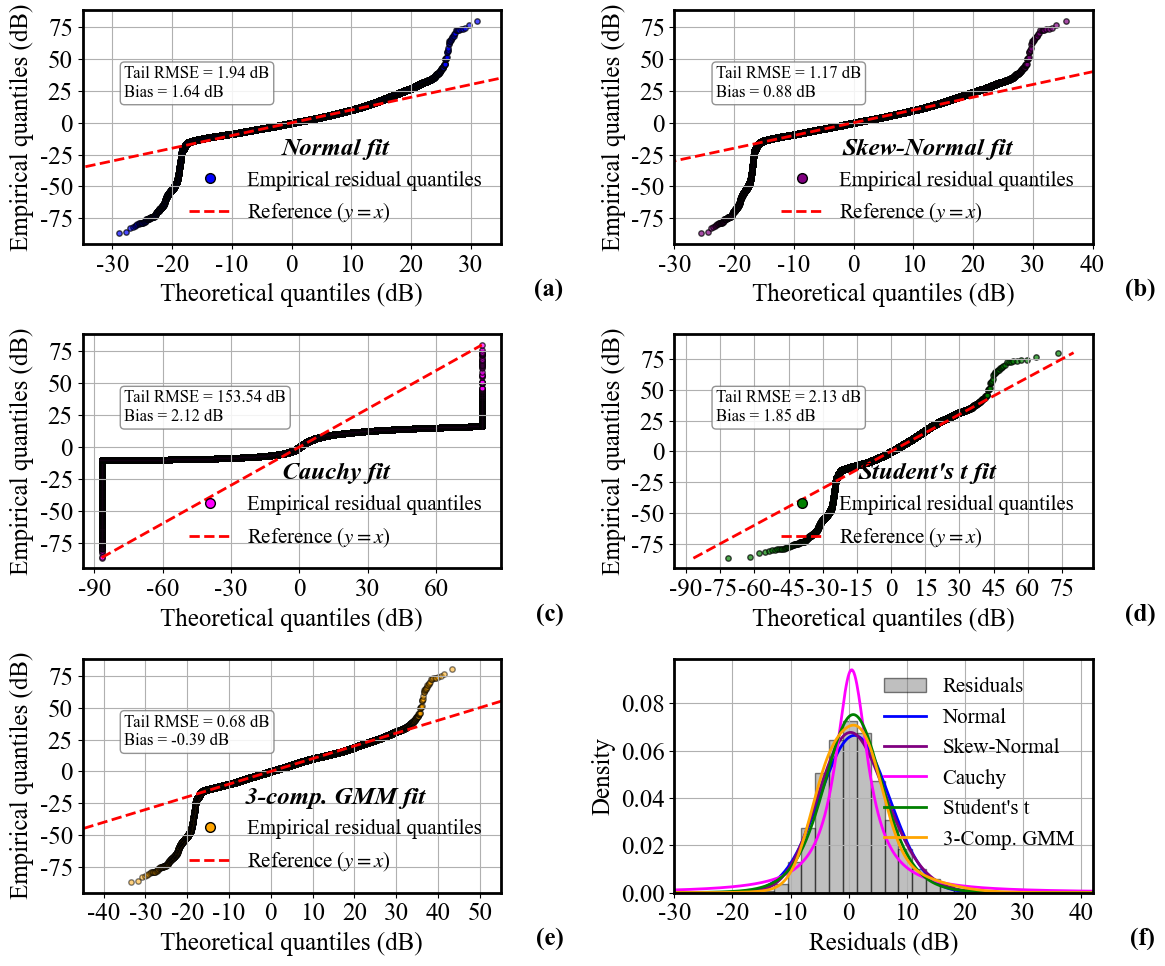

In [57]:
# Plot Diagnostic Subplots in a 3x2 Grid
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'legend.fontsize': 15
})

QQ_POINT_SIZE = 15
LINEWIDTH = 2

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

def qq_legend(ax, title, color):
    handles = [
        Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=color, markeredgecolor='k', markersize=7, label='Empirical residual quantiles'),
        Line2D([0], [0], color='r', linestyle='--', linewidth=LINEWIDTH, label=r'Reference ($y=x$)')
    ]
    leg = ax.legend(handles=handles, loc='lower right', frameon=False, title=rf'{title} fit')
    leg.get_title().set_fontstyle('italic')
    leg.get_title().set_fontweight('bold')


def add_tail_error_text(ax, table_name, tail_error_table):
    row = tail_error_table[
        (tail_error_table["distribution"] == table_name)
        & (tail_error_table["tail"] == "both")
    ]

    if row.empty:
        return

    row = row.iloc[0]

    txt = (
        f"Tail RMSE = {row['tail_rmse']:.2f} dB\n"
        f"Bias = {row['tail_bias']:.2f} dB"
    )

    ax.text(0.1, 0.76, txt, transform=ax.transAxes, ha='left', va='top', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='0.5', alpha=0.85),
        zorder=10
    )


def manual_qq_plot(distribution, display_name, table_name, sorted_residuals, probabilities, ax, color='blue'):
    theoretical_quantiles = distribution.ppf(probabilities)

    ax.scatter(theoretical_quantiles, sorted_residuals, s=QQ_POINT_SIZE, edgecolors='k', facecolor=color, alpha=0.7)

    min_val = min(theoretical_quantiles.min(), sorted_residuals.min())
    max_val = max(theoretical_quantiles.max(), sorted_residuals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=LINEWIDTH)

    ax.set_xlabel('Theoretical quantiles (dB)')
    ax.set_ylabel('Empirical quantiles (dB)')
    ax.grid(True)

    qq_legend(ax, display_name, color)
    add_tail_error_text(ax, table_name, qq_tail_error_table)


# 1) Q-Q Plot (Normal)
manual_qq_plot(normal_dist, 'Normal', 'Normal', sorted_residuals, probabilities, axes[0], color='blue')
axes[0].text(1.15, -0.15, subplot_labels[0], transform=axes[0].transAxes, ha='right', va='top', fontweight='bold', fontsize=18)
axes[0].set_xlim(-35, 35)


# 2) Q-Q Plot (Skew-Normal)
manual_qq_plot(skew_dist, 'Skew-Normal', 'SkewNormal', sorted_residuals, probabilities, axes[1], color='purple')
axes[1].text(1.15, -0.15, subplot_labels[1], transform=axes[1].transAxes, ha='right', va='top', fontweight='bold', fontsize=18)
axes[1].set_xlim(-30, 40)


# 3) Q-Q Plot (Cauchy)
lower_bound = residuals.min()
upper_bound = residuals.max()
theoretical_quantiles = cauchy_dist.ppf(probabilities)
theoretical_quantiles_clipped = np.clip(theoretical_quantiles, lower_bound, upper_bound)

axes[2].scatter(theoretical_quantiles_clipped, sorted_residuals, s=QQ_POINT_SIZE, edgecolors='k', facecolor='magenta', alpha=0.7)
axes[2].plot([lower_bound, upper_bound], [lower_bound, upper_bound], 'r--', linewidth=LINEWIDTH)

axes[2].set_xlabel('Theoretical quantiles (dB)')
axes[2].set_ylabel('Empirical quantiles (dB)')
axes[2].grid(True)
qq_legend(axes[2], 'Cauchy', 'magenta')
add_tail_error_text(axes[2], 'Cauchy', qq_tail_error_table)

axes[2].text(1.15, -0.15, subplot_labels[2], transform=axes[2].transAxes, ha='right', va='top', fontweight='bold', fontsize=18)


# 4) Q-Q Plot (Student's t)
manual_qq_plot(t_dist, "Student's t", 'StudentT', sorted_residuals, probabilities, axes[3], color='green')
axes[3].text(1.15, -0.15, subplot_labels[3], transform=axes[3].transAxes, ha='right', va='top', fontweight='bold', fontsize=18)
axes[3].set_ylim(-95, 95)


# 5) Q-Q Plot (GMM)
x_grid = np.linspace(residuals.min(), residuals.max(), 200000)
cdf_grid = gmm_cdf(x_grid, best_gmm)
unique_cdf, unique_indices = np.unique(cdf_grid, return_index=True)
unique_x = x_grid[unique_indices]
ppf_func = interp1d(unique_cdf, unique_x, bounds_error=False, fill_value=(x_grid[0], x_grid[-1]))
theoretical_gmm_quantiles = ppf_func(probabilities)

axes[4].scatter(theoretical_gmm_quantiles, sorted_residuals, s=QQ_POINT_SIZE, edgecolors='k', facecolor='orange', alpha=0.5)
min_val = min(theoretical_gmm_quantiles.min(), sorted_residuals.min())
max_val = max(theoretical_gmm_quantiles.max(), sorted_residuals.max())
axes[4].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=LINEWIDTH)

axes[4].set_xlabel('Theoretical quantiles (dB)')
axes[4].set_ylabel('Empirical quantiles (dB)')
axes[4].grid(True)
qq_legend(axes[4], f'{best_gmm.n_components}-comp. GMM', 'orange')
add_tail_error_text(axes[4], f'GMM(K={best_gmm.n_components})', qq_tail_error_table)

axes[4].text(1.15, -0.15, subplot_labels[4], transform=axes[4].transAxes, ha='right', va='top', fontweight='bold', fontsize=18)
axes[4].set_xlim(-45, 55)


# 6) Residuals Histogram with Fitted Densities
axes[5].hist(residuals, bins=70, density=True, alpha=0.5, color='grey', edgecolor='black', label='Residuals')

x_vals = np.linspace(residuals.min(), residuals.max(), 1000)

axes[5].plot(x_vals, normal_dist.pdf(x_vals), label='Normal', color='blue', linewidth=LINEWIDTH)
axes[5].plot(x_vals, skew_dist.pdf(x_vals), label='Skew-Normal', color='purple', linewidth=LINEWIDTH)
axes[5].plot(x_vals, cauchy_dist.pdf(x_vals), label='Cauchy', color='magenta', linewidth=LINEWIDTH)
axes[5].plot(x_vals, t_dist.pdf(x_vals), label="Student's t", color='green', linewidth=LINEWIDTH)

gmm_density = np.exp(best_gmm.score_samples(x_vals.reshape(-1, 1)))
axes[5].plot(x_vals, gmm_density, label=f'{best_gmm.n_components}-Comp. GMM', color='orange', linewidth=LINEWIDTH)

axes[5].set_xlabel('Residuals (dB)')
axes[5].set_ylabel('Density')
axes[5].legend(fontsize=15, frameon=False)
axes[5].grid(True)
axes[5].set_xlim(-30, 42)
axes[5].text(1.15, -0.15, subplot_labels[5], transform=axes[5].transAxes, ha='right', va='top', fontweight='bold', fontsize=18)


# Tick Interval Adjustments
axes[0].xaxis.set_major_locator(MultipleLocator(10))
axes[0].yaxis.set_major_locator(MultipleLocator(25))

axes[1].xaxis.set_major_locator(MultipleLocator(10))
axes[1].yaxis.set_major_locator(MultipleLocator(25))

axes[2].xaxis.set_major_locator(MultipleLocator(30))
axes[2].yaxis.set_major_locator(MultipleLocator(25))

axes[3].xaxis.set_major_locator(MultipleLocator(15))
axes[3].yaxis.set_major_locator(MultipleLocator(25))

axes[4].xaxis.set_major_locator(MultipleLocator(10))
axes[4].yaxis.set_major_locator(MultipleLocator(25))

axes[5].xaxis.set_major_locator(MultipleLocator(10))
axes[5].yaxis.set_major_locator(MultipleLocator(0.02))

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=18)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor("black")

plt.tight_layout()
#plt.savefig('Figures/qq_residual_plots.png', dpi=1000)
plt.show()